# Import libraries

In [2]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [3]:
c = 299792.458 #is this in the correct units?
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)
megaparsec = 3.0856775814913673 * 10**10

# Some key functions

In [4]:
#order of variables: z, omega_k, omega_M, omega_DE, H0, rc

def eos(z, w):
    return w[0] + w[1]*(np.log(2+z)/(1+z) - np.log(2))

def Friedmann_eq2(z, theta):
    omega_k, omega_DE, H0, w0, w1 = theta
    w = eos(z, [w0, w1])
    omega_M = 1 - omega_k - omega_DE
    H2 = (omega_M*(1+z)**3 + omega_DE*(1+z)**(3*(1+w)) - omega_k*(1+z)**2)
    #print(H2)
    return H2

def integrand(z, theta):
    return 1/np.sqrt(Friedmann_eq2(z, theta))

def co_moving_dist(z_up, theta):
    z_up = np.concatenate(([0], z_up))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, theta), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c)

def Sk(omega_k, H0, rc): #units issue?
    if omega_k == 0:
        return c*rc/H0
    if omega_k < 0:
        return (c/(H0*np.sqrt(-omega_k)))*np.sin(np.sqrt(-omega_k)*rc)
    return (c/(H0*np.sqrt(omega_k)))*np.sinh(np.sqrt(omega_k)*rc)

def dist_modulus(z, theta):
    omega_k = theta[0]
    H0 = theta[2]
    #print(f"H0 is {H0}")
    rc = co_moving_dist(z, theta)
    s_k = Sk(omega_k, H0, rc)
    dl = (1+z)*s_k
    #if not np.all(dl>0):
        #print(f"luminosity distance isn't positive, params are: {theta}\n")
        #for i in range(len(dl)):
            #print(f"{dl[i]}, {s_k[i]}, {rc[i]}")
    dist_mod = 5*np.log10(dl) + 25
    return dist_mod

# Load the data

In [5]:
sn_z, sn_z_err, sn_mu, sn_mu_err = np.loadtxt("pantheon-plus+SH0ES-SN.txt", usecols=(2,3,4,5), unpack = True)
covmat_file = np.loadtxt("Pantheon+SH0ES_STAT+SYS.cov")
covmat_file_dim = int(covmat_file[0])
covmat_file = np.delete(covmat_file, 0)
covmat = np.zeros((covmat_file_dim, covmat_file_dim))
covmat.shape
for i in range(covmat_file_dim):
    covmat[i] = covmat_file[i*covmat_file_dim:(i+1)*covmat_file_dim]
covmat_inv = np.linalg.inv(covmat)


## Priors

Parameters of model are: {k, H0, omega_M, omega_DE}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [6]:
H0_prior = 73.3
H0_stdev_prior = 1.04
omega_DE_prior = 0.685
omega_DE_stdev_prior = 0.017

def log_prior(theta, z):
    omega_k, omega_DE, H0, w0, w1 = theta
    H2 = Friedmann_eq2(z, theta)
    if not (-1<omega_k<1 and np.all(H2>0) and -3<w0<-0.01 and 20<H0<100 and -4<w1<9):
        return -np.inf
    return -0.5*(omega_DE-omega_DE_prior)**2/omega_DE_stdev_prior**2

nparams = 5
nwalkers = 32
pos = np.zeros((nwalkers, nparams))
for i in range(len(pos)):
    pos[i][0] = np.random.uniform(-0.005, 0.005)
    pos[i][1] = np.random.uniform(0.6, 0.75)
    pos[i][2] = np.random.uniform(20, 100)
    pos[i][3] = np.random.uniform(-2,-0.01)
    pos[i][4] = np.random.uniform(-4,9)
    

# Likelihood function

In [7]:
def log_likelihood(theta, z, mu, covmatrix_inv):
    model = dist_modulus(z, theta)
    resids = mu - model
    chi2 = np.matmul(np.matmul(resids, covmatrix_inv), resids)
    return -0.5*chi2
    


def log_probability(theta, z, mu, covmatrix_inv):
    lp = log_prior(theta, z)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [8]:
nsteps = 5000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mu, covmat_inv)
)
sampler.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 5000/5000 [08:18<00:00, 10.03it/s]


State([[-2.29236283e-01  7.00078358e-01  6.00158099e+01 -8.92538900e-01
   8.69737984e+00]
 [-1.99805761e-02  6.63977761e-01  7.08099708e+01 -6.48068386e-01
   5.04066759e+00]
 [ 1.63588435e-01  6.70543016e-01  8.84589253e+01 -6.31551243e-01
  -8.90711445e-01]
 [-1.09356264e-01  6.83711253e-01  6.57478635e+01 -8.44114255e-01
   5.21720852e+00]
 [-7.27553517e-02  6.59103694e-01  6.72451494e+01 -7.19389293e-01
   4.88775224e+00]
 [ 3.89503907e-02  6.71537148e-01  7.52422505e+01 -7.31707420e-01
   1.15349252e+00]
 [-2.20312400e-01  7.02162013e-01  6.07172875e+01 -1.09819737e+00
   7.06502937e+00]
 [-4.94686971e-02  7.01439111e-01  6.95214881e+01 -9.52009306e-01
   1.41010027e-01]
 [-7.28782281e-02  6.69006491e-01  6.74711883e+01 -8.10806746e-01
   3.06875765e+00]
 [-1.19903851e-01  6.87631419e-01  6.50935301e+01 -9.07383330e-01
   4.59912874e+00]
 [-8.83499688e-03  6.88750918e-01  7.14088393e+01 -6.78274520e-01
   2.36781563e+00]
 [ 3.79387808e-02  6.98828607e-01  7.60193044e+01 -8.676474

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 494;
tau: [623.99585852 158.9080744  665.31701794 165.74440625 462.70311009]

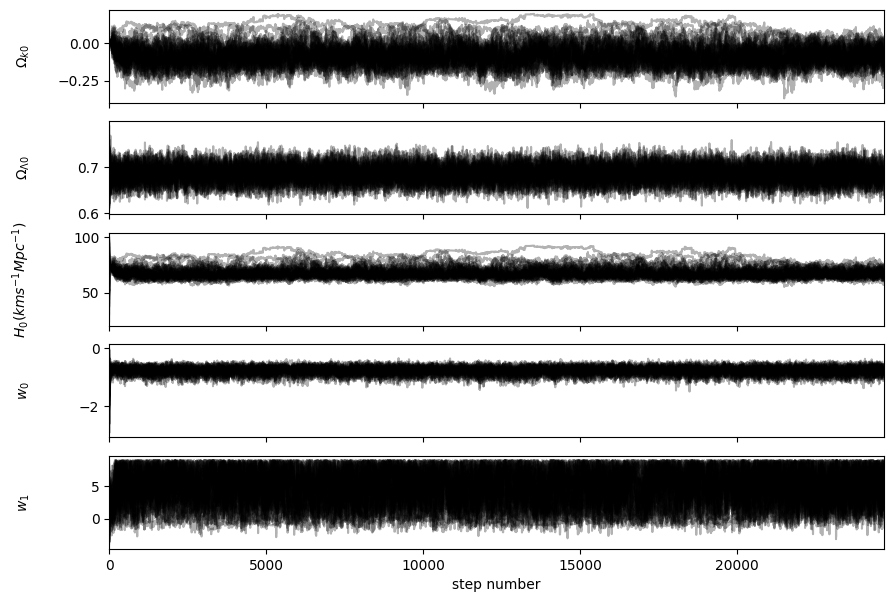

In [10]:
#sampler.run_mcmc(None, 50000, progress = True)
ndiscard = 100 #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(nparams, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["$Ω_{k0}$", "$Ω_{Λ0}$", "$H_{0} (kms^{-1}Mpc^{-1})$", "$w_{0}$", "$w_{1}$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.savefig("walkers_logCDM.png")
print(f"autocorrelation time is {sampler.get_autocorr_time()}")

# Covariance plots

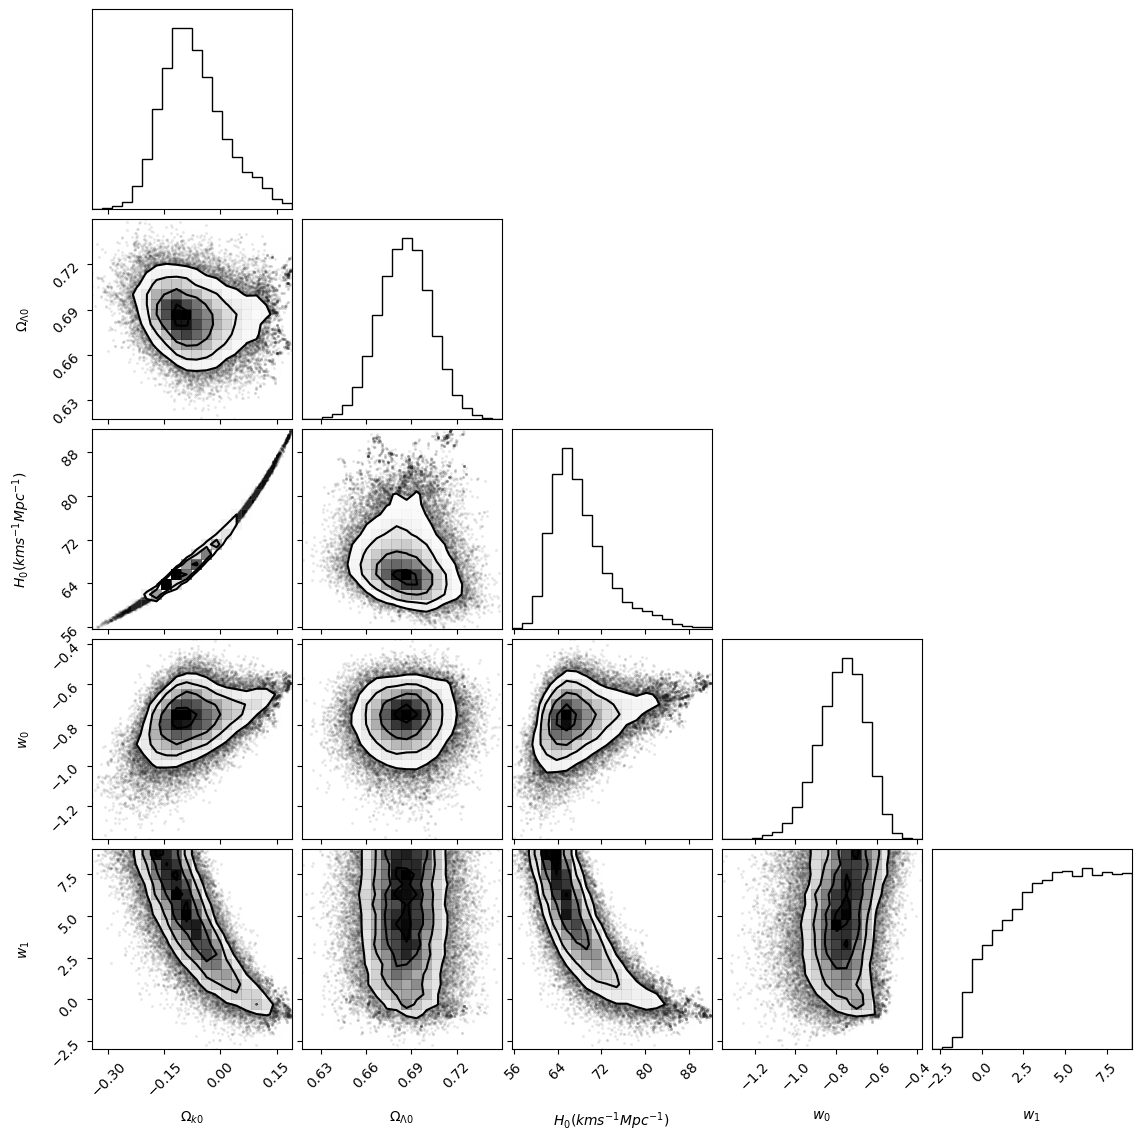

In [11]:

fig = corner.corner(
    flat_samples, labels = labels
)
plt.savefig("corner_logCDM.png")

In [ ]:


for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]} + {q[1]} - {q[0]}")

$Ω_{k0}$: -0.22381843354281983 + 0.16886580497497883 - 0.13585479435984316
$Ω_{Λ0}$: 0.684161024925901 + 0.017828510276479026 - 0.016462431799910804
$H_{0} (kms^{-1}Mpc^{-1})$: 59.81688534801344 + 8.8874932179653 - 5.2152873291029636
$w_{0}$: -0.5538642873190291 + 0.5186680753908347 - 0.22682447082670854
$w_{1}$: -3.2606410400420476 + 2.511071547606566 - 4.070071183123663


In [ ]:
theta_model = np.zeros(nparams)
for i in range(nparams):
    theta_model[i] = np.percentile(flat_samples[:, i], [50])[0]

In [12]:
model_z = np.linspace(0.001, 2.3, 1000)
model_mu = dist_modulus(model_z, theta_model)
resids = sn_mu - dist_modulus(sn_z, theta_model)
chisqval = np.matmul(np.matmul(resids, covmat_inv), resids)


fig, axs = plt.subplots(2, 2, width_ratios=[4,1], height_ratios=[2,1])
axs[0,0].plot(model_z, model_mu, color = "maroon", zorder = 2)

axs[0,0].errorbar(sn_z, sn_mu, xerr=sn_z_err, yerr = sn_mu_err, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(2,0,2.3, linestyle = "--", color = "black")
norm_resids = (dist_modulus(sn_z, theta_model) - sn_mu)/sn_mu_err
print(f"chi-squared: {chisqval}")
axs[1,0].errorbar(sn_z, norm_resids, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-2,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(0,0,2.3, linestyle = "--", color = "black", zorder = 2)
axs[1,0].set_xlabel("redshift")
axs[0,0].set_ylabel("distance modulus (mag)")
axs[1,0].set_ylabel("distance modulus\nresiduals (mag)")
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
#axs[0,0].invert_yaxis()
axs[0,0].set_xscale("log")
axs[1,0].set_xscale("log")
axs[0,1].remove()
axs[1,1].get_yaxis().set_visible(False)
xs = np.linspace(-3,3)
axs[1,1].plot(scp.stats.norm.pdf(xs, 0, 1), xs)
axs[1,1].set_xlabel("Probability\ndensity")
axs[1,1].hist(norm_resids, density = True, orientation = u'horizontal', bins = np.linspace(-3, 3, 20))
plt.savefig("plot_LCDM", bbox_inches = "tight")
plt.show()
BIC = nparams*np.log(covmat_file_dim) + chisqval
print(f"BIC: {BIC}")

NameError: name 'theta_model' is not defined